# Feature Choiche
Questo notebook viene utilizzato per scegliere le feature realizzate nel notebook [feature-engineering](feature-engineering.ipynb) da utilizzare nella parte di machine learning. 

## Caricamento del dataset
Per prima cosa deve essere caricato il dataset ottenuto dal notebook precedente, per effettuare la scelta dei dati da utilizzare. La seguente parte di codice viene utilizzata per importarlo

In [49]:
import pandas as pd

path = "static/da-result/result.csv"
dataset = pd.read_csv(path)

list(dataset)

['Date',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'Season',
 'Home_WinStreak',
 'Away_WinStreak',
 'AvgH_Goals_Last5',
 'AvgH_Wins_Last5',
 'AvgA_Goals_Last5',
 'AvgA_Wins_Last5',
 'GoalOnShotRatioHome',
 'GoalOnShotRatioAway',
 'HomeAdvantage',
 'PointToMatchRatioHome',
 'PointToMatchRatioAway']

## Ricerca di feature ridondanti
Per effettuare la ricerca di feature ridondanti, costruiamo une heatmap con tutte le caratteristiche estratte dal dataset. Se due feature hanno una relazione elevata, possiamo considerarle **ridondanti**, e quindi utilizzarne solamente una delle due (la scelta verrà demandata alla parte di machine learning). Per comodità viene visualizzata la heatmap delle sole caratteristiche della squadra di casa (che sono equivalenti a quella delle squadre in trasferta). 

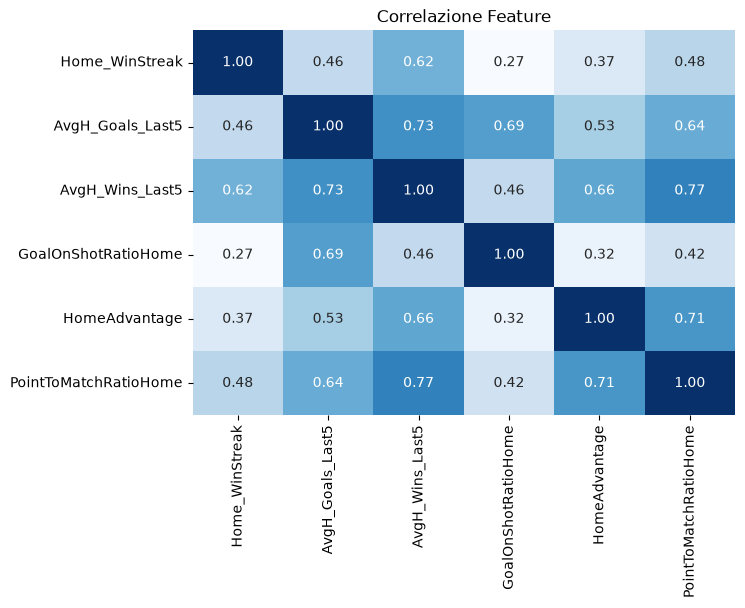

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap per le feature
plt.figure(figsize=(7, 5))

features = ["Home_WinStreak", "AvgH_Goals_Last5", "AvgH_Wins_Last5", "GoalOnShotRatioHome", "HomeAdvantage", "PointToMatchRatioHome"]
sns.heatmap(dataset[features].corr(), annot=True, cmap='Blues', fmt=".2f", cbar=False)

plt.title('Correlazione Feature')
plt.show()


Notiamo che nella tabella appena generata ci sono molte feature ridondanti, in particolare:
- PointToMatchRatio e AvgH_Wins_Last5;
- PointToMatchRatio e HomeAdvantage;
- GoalOnShotRatio e Avg_Goals_Last5;
- Avg_Wins_Last5 e Home_WinStreak;
- Avg_Wins_Last5 e Avg_Goals_Last5

altre invece sono meno correlate, e possiamo quindi utilizzarle insieme nelle operazioni di machine learning. 

## Regressione Logistica per la scelta delle feature
Una volta ottenuta la tabella relativa alla correlazione delle feature, utilizziamo la regressione logistica per la scelta delle fetaure migliori per effettuare la predizione dei risultati delle partite. Per farlo utilizziamo la libreria **scikit-learn**, in particolare la sua classe **LogisticRegression**. Per prima cosa suddividiamo il dataset in training e set, utilizzando la divisione temporale; trasformo le classi di output in valori numerici (A, D, H) -> (0, 1, 2)

In [51]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

Y = dataset["FTR"]
X = dataset.drop(columns=['FTR', 'Date','HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'Season'])

label_encoder = LabelEncoder()

Y_ENCODED = label_encoder.fit_transform(Y)

split_index = int(len(X) * 0.8)


Y_train, Y_test = Y_ENCODED[:split_index], Y_ENCODED[split_index:]
X.head()

,Home_WinStreak,Away_WinStreak,AvgH_Goals_Last5,AvgH_Wins_Last5,AvgA_Goals_Last5,AvgA_Wins_Last5,GoalOnShotRatioHome,GoalOnShotRatioAway,HomeAdvantage,PointToMatchRatioHome,PointToMatchRatioAway
0,1,0,1.2,0.4,0.6,0.2,0.250000,0.180000,0.2,0.921053,1.078947
1,2,2,1.0,0.4,1.0,0.6,0.190000,0.345238,0.2,0.894737,1.789474
2,0,0,0.8,0.4,1.4,0.4,0.373333,0.295238,0.2,1.105263,1.289474
3,1,0,1.8,0.4,1.4,0.4,0.288889,0.202381,0.6,1.921053,1.315789
4,1,1,1.0,0.4,1.0,0.4,0.177778,0.250000,0.4,1.842105,1.052632


Successivamente genero un'istanza della classe LogisticRegression per effettuare le operazioni elencate precedentemente. 

Creo la funzione **evaluate_features** che richeiede in inupt un array di stringhe (le feature che ci interessa valutare) e in output ritorna l'accuratezza dei singoli parametri generati.

In [52]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

def evaluate_features(subset_features: list[str]):
    global X

    model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    )
    
    NEW_X = X.drop(columns=subset_features)
    NEW_X.head()
    scaler = StandardScaler()
    X_SCALED = scaler.fit_transform(NEW_X)
    
    X_train, X_test = X_SCALED[:split_index], X_SCALED[split_index:]
    
    model.fit(X_train, Y_train)
    prediction = model.predict(X_test)

    return accuracy_score(Y_test, prediction)


Adesso si possono ottenere i risultati delle feature

In [53]:
print(evaluate_features(['AvgH_Goals_Last5', 'AvgA_Goals_Last5', 'AvgH_Wins_Last5', 'AvgA_Wins_Last5', 'Home_WinStreak',
 'Away_WinStreak']))

0.48464912280701755
